# Exercises: Optimization

**Lecture 6 · questions and answers**

**In class**, for every question: work on your own or with a neighbour → submit your answer in Socrative → we go through the solution together.

Each question states the section of `01_Optimization.ipynb` it builds on, and every exercise supplies its own inputs, so you can start anywhere.

Try each question first, then open the hint if needed. Reveal the solution only after an attempt.

### Socrative room: PROGECON26

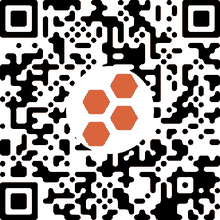

Scan the code or open the [PROGECON26 room](https://api.socrative.com/rc/vzHVjE?method=qr). Every box marked **Socrative** says what to submit: usually one number, one choice or one sentence.

## Setup

In [1]:
import numpy as np
from scipy import optimize


def u_func(x1, x2, alpha):
    """Utility for nonnegative quantities; 0 < alpha < 1."""
    return x1**alpha * x2**(1 - alpha)

## Q1. How good is a budget-line grid? · Sections 2–3

The consumer likes both goods and does not save, so we search the budget line $x_2=(I-p_1x_1)/p_2$.

In [5]:
# inputs for Q1
alpha = 0.35
I = 12.0
p1 = 2.0
p2 = 1.0
N = 9

**1a.** Create `N` evenly spaced quantities of good 1 from 0 to `I/p1`, the matching quantities of good 2, and utility for every pair.

**1b.** Which grid point is best? Use `np.argmax`, print both quantities, utility and budget left, and check that the bundle is affordable.

> **Socrative:** the best quantity of good 1 on the 9-point grid.

In [6]:
# Q1a and Q1b

<details>
<summary><strong>Show hint</strong></summary>

`np.linspace` gives the first array; array arithmetic gives the second; `u_func` works on whole arrays. `np.argmax` returns a **position**: use it in both quantity arrays.

</details>

<details>
<summary><strong>Reveal solution</strong></summary>

```python
# a. Create the grid and evaluate utility
x1_grid = np.linspace(0.0, I/p1, N)
x2_grid = (I - p1*x1_grid)/p2
utility_grid = u_func(x1_grid, x2_grid, alpha)

# b. Find and check the best bundle
best_index = np.argmax(utility_grid)
x1_best = x1_grid[best_index]
x2_best = x2_grid[best_index]
remaining_budget = I - p1*x1_best - p2*x2_best

print(f'Bundle: ({x1_best:.4f}, {x2_best:.4f})')
print(f'Utility: {utility_grid[best_index]:.6f}')
print(f'Budget left: {remaining_budget:.8f}')
print('Affordable:', remaining_budget >= -1e-8)
```

The best grid bundle is **(2.25, 7.5)**. It spends the whole budget, so the budget left is zero. `best_index` is the position of the best point; use that position in both quantity arrays.

</details>

**1c.** Does a finer grid help? Repeat with 33 points and compare the error in good 1 with the benchmark $x_1^*=\alpha I/p_1$ for both grids. Why can more points still miss the exact optimum?

> **Socrative:** the two errors, rounded to two decimals.

In [7]:
# Q1c

<details>
<summary><strong>Show hint</strong></summary>

Only the `np.linspace` call changes. The 9-point grid is contained in the 33-point grid, so the best utility cannot fall. The optimum can still lie between two grid points.

</details>

<details>
<summary><strong>Reveal solution</strong></summary>

```python
x1_exact = alpha*I/p1

for n_points in [9, 33]:
    x1_grid = np.linspace(0.0, I/p1, n_points)
    x2_grid = (I - p1*x1_grid)/p2
    utility_grid = u_func(x1_grid, x2_grid, alpha)
    best_index = np.argmax(utility_grid)
    x1_best = x1_grid[best_index]
    error = abs(x1_best - x1_exact)

    print(f'{n_points} points: x1 = {x1_best:.4f}, error = {error:.2f}')
```

The errors are **0.15** with 9 points and **0.04** with 33 points. The exact quantity is 2.1, while the finer grid selects 2.0625. More points help here, but the exact optimum still lies between grid points.

</details>

## Q2. What happens when the budget grows? · Section 4

Same preferences and prices, two budgets. The objective below spends the whole budget and returns negative utility.

In [8]:
# inputs for Q2
alpha = 0.4
p1 = 2.0
p2 = 1.0
I_low = 20.0
I_high = 30.0


def negative_utility(x1, alpha, I, p1, p2):
    x2 = (I - p1*x1)/p2
    return -u_func(x1, x2, alpha)

**2a.** Solve for `I_low` with `optimize.minimize_scalar(..., method='bounded')`. Check `.success`, then print the bundle, utility, budget left and `.nfev`.

> **Socrative:** the quantity of good 1 and the number of evaluations.

**2b.** Predict first: what happens to both quantities when income rises to `I_high`? Then solve. Remember to update both `args` and `bounds`.

> **Socrative:** the new quantity of good 1 and one sentence on what changed.

In [9]:
# Q2a and Q2b

<details>
<summary><strong>Show hint</strong></summary>

`args` follows the order of the function definition after the choice `x1`. Use the same income in `args`, the upper bound, the good-2 calculation and the budget check. Give the two results different names.

</details>

<details>
<summary><strong>Reveal solution</strong></summary>

```python
# a. Solve with the lower income
result_low = optimize.minimize_scalar(
    negative_utility,
    args=(alpha, I_low, p1, p2),
    bounds=(0.0, I_low/p1),
    method='bounded'
)
print('Solver success:', result_low.success)
if not result_low.success:
    raise RuntimeError(result_low.message)

x1_low = result_low.x
x2_low = (I_low - p1*x1_low)/p2
print(f'Low-income bundle: ({x1_low:.4f}, {x2_low:.4f})')
print(f'Utility: {u_func(x1_low, x2_low, alpha):.6f}')
print(f'Budget left: {I_low - p1*x1_low - p2*x2_low:.8f}')
print(f'Function evaluations: {result_low.nfev}')

# b. Predict the change, then solve with the higher income
print(f'Predicted x1 at higher income: {x1_low*I_high/I_low:.4f}')
result_high = optimize.minimize_scalar(
    negative_utility,
    args=(alpha, I_high, p1, p2),
    bounds=(0.0, I_high/p1),
    method='bounded'
)
print('Solver success:', result_high.success)
if not result_high.success:
    raise RuntimeError(result_high.message)

x1_high = result_high.x
x2_high = (I_high - p1*x1_high)/p2
print(f'High-income bundle: ({x1_high:.4f}, {x2_high:.4f})')
print(f'Budget left: {I_high - p1*x1_high - p2*x2_high:.8f}')
```

The bundles are approximately **(4, 12)** and **(6, 18)**. Income rises by 50%, and both goods rise by 50%: with these Cobb–Douglas preferences and fixed prices, each good receives a fixed share of income. The lower-income solve uses about 10 function evaluations; the count can differ across SciPy versions.

</details>

## Q3. Which restriction binds? · Section 5

The consumer's cupboard holds **at most 6 units in total**: $x_1+x_2\leq 6$. This restriction links both goods, just like the budget.

In [10]:
# inputs for Q3
alpha = 0.5
I = 12.0
p1 = 1.0
p2 = 2.0
storage = 6.0
initial_guess = np.array([1.0, 1.0])


def negative_utility_bundle(x, alpha):
    return -u_func(x[0], x[1], alpha)


def budget_left(x, I, p1, p2):
    return I - p1*x[0] - p2*x[1]

**3a.** Write `storage_left(x, storage)`, which is nonnegative when the bundle fits. Build the bounds and **two** constraint dictionaries, and call `optimize.minimize` with `method='SLSQP'`.

**3b.** Check `.success`, then print the bundle, budget left and storage left. Which restriction is tight? Is the whole budget spent, and why is that not a mistake?

> **Socrative:** the bundle and which restriction is tight: budget, storage, both or neither.

*Optional:* drop the storage restriction and solve again. Does the new bundle fit in the cupboard?

In [11]:
# Q3a and Q3b

<details>
<summary><strong>Show hint</strong></summary>

`constraints` accepts a list of dictionaries, one per restriction: `[budget_constraint, storage_constraint]`. Each `'fun'` must be nonnegative at allowed bundles. With a full cupboard, extra money cannot buy anything useful.

</details>

<details>
<summary><strong>Reveal solution</strong></summary>

```python
# a. Define both restrictions and solve
def storage_left(x, storage):
    return storage - x[0] - x[1]


quantity_bounds = [(0.0, I/p1), (0.0, I/p2)]
budget_constraint = {
    'type': 'ineq',
    'fun': budget_left,
    'args': (I, p1, p2)
}
storage_constraint = {
    'type': 'ineq',
    'fun': storage_left,
    'args': (storage,)
}
result_storage = optimize.minimize(
    negative_utility_bundle,
    x0=initial_guess,
    args=(alpha,),
    method='SLSQP',
    bounds=quantity_bounds,
    constraints=[budget_constraint, storage_constraint]
)
print('Solver success:', result_storage.success)
if not result_storage.success:
    raise RuntimeError(result_storage.message)

# b. Check which restriction is tight
x1_storage, x2_storage = result_storage.x
print(f'Bundle: ({x1_storage:.4f}, {x2_storage:.4f})')
print(f'Budget left: {budget_left(result_storage.x, I, p1, p2):.8f}')
print(f'Storage left: {storage_left(result_storage.x, storage):.8f}')

# Optional: solve without the storage restriction
result_no_storage = optimize.minimize(
    negative_utility_bundle,
    x0=initial_guess,
    args=(alpha,),
    method='SLSQP',
    bounds=quantity_bounds,
    constraints=budget_constraint
)
print('Solver success:', result_no_storage.success)
if not result_no_storage.success:
    raise RuntimeError(result_no_storage.message)

x1_no_storage, x2_no_storage = result_no_storage.x
print(f'Without storage: ({x1_no_storage:.4f}, {x2_no_storage:.4f})')
print(f'Total units: {x1_no_storage + x2_no_storage:.4f}')
print('Fits in the cupboard:',
      storage_left(result_no_storage.x, storage) >= -1e-8)
```

The bundle is approximately **(3, 3)**: storage left is zero, but budget left is 3. **Storage binds; the budget does not.** With a full cupboard, spending more would require giving up another unit, so the consumer leaves money unspent. Without the storage restriction, the bundle is approximately **(6, 3)**. Its 9 units exceed the cupboard capacity of 6.

</details>